# Applied Economics Software II — Week 6  
## Working with World Bank and Yahoo Finance Data in Python
### Prepared by
**Eren Eskicioğlu**
[GitHub](https://github.com/MrESKK)


This notebook introduces two practical data sources frequently used in applied economics and finance.  
The first part shows how to access macroeconomic indicators from the **World Bank Database** by using the `wbgapi` package.  
The second part explains how to download and visualize financial market data from **Yahoo Finance** by using the `yfinance` package.


## Installing the Required Package

The first step is to install the `wbgapi` package, which provides access to World Bank data directly from Python.


In [1]:
!pip install wbgapi

## Importing the Required Libraries

The following libraries are used in the World Bank data section.


In [2]:
import wbgapi as wb
import pandas as pd

# Accessing Data from the World Bank Database

In this section, the notebook explores the basic tools available in the `wbgapi` library.  
These commands help inspect available series, search indicators, and retrieve country-level data.


## Checking the Loaded Package

This command prints the imported package object to confirm that it has been loaded successfully.


In [ ]:
print(wb)

<module 'wbgapi' from '/usr/local/lib/python3.12/dist-packages/wbgapi/__init__.py'>


## Viewing Help for Series Information

The following command displays help documentation for the `series` module.


In [ ]:
help(wb.series)

Help on module wbgapi.series in wbgapi:

NAME
    wbgapi.series - Access information about series in a database

FUNCTIONS
    Series(id='all', q=None, topic=None, db=None, name='SeriesName')
        Return a pandas Series by calling list

    get(id, db=None)
        Retrieve a specific series object

        Arguments:
            id:     the series identifier

            db:     database; pass None to access the global database

        Returns:
            a series object

        Example:
            print(wbgapi.series.get('SP.POP.TOTL')['value'])

    info(id='all', q=None, topic=None, db=None)
        Print a user report of series. This can be time consuming
        for large databases like the WDI if 'all' series are requested.

        Arguments:
            id:         a series identifier or list-like of identifiers

            q:          search string (on series name))

            topic:      topic ID or list-like

            db:         database; pass None to access t

## Listing Available Series

This step shows the available indicator series in the World Bank database.


In [ ]:
wb.series.info()

id,value
AG.CON.FERT.PT.ZS,Fertilizer consumption (% of fertilizer production)
AG.CON.FERT.ZS,Fertilizer consumption (kilograms per hectare of arable land)
AG.LND.AGRI.K2,Agricultural land (sq. km)
AG.LND.AGRI.ZS,Agricultural land (% of land area)
AG.LND.ARBL.HA,Arable land (hectares)
AG.LND.ARBL.HA.PC,Arable land (hectares per person)
AG.LND.ARBL.ZS,Arable land (% of land area)
AG.LND.CREL.HA,Land under cereal production (hectares)
AG.LND.CROP.ZS,Permanent cropland (% of land area)
AG.LND.EL5M.RU.K2,Rural land area where elevation is below 5 meters (sq. km)


## Example Indicator Codes

The following notes show example indicator codes related to exports and imports.


In [ ]:
# NE.EXP.GNFS.CD Exports of goods and services (current US$)
# NE.IMP.GNFS.CD Merchandise imports (current US$)

## Inspecting a Specific Series

This example displays information for the series `NE.EXP.GNFS.CD`, which represents exports of goods and services in current US dollars.


In [3]:
wb.series.info("NE.EXP.GNFS.CD")

id,value
NE.EXP.GNFS.CD,Exports of goods and services (current US$)
,1 elements


## Viewing Selected Economies

This command displays information for Canada, the United States, and Mexico.


In [ ]:
wb.economy.info(["CAN","USA","MEX"])

id,value,region,incomeLevel
CAN,Canada,NAC,HIC
MEX,Mexico,LCN,UMC
USA,United States,NAC,HIC
,3 elements,,


## Searching for an Indicator by Keyword

This search looks for indicators related to final consumption expenditure.


In [4]:
wb.search("final consumption expenditure")


ID,Name,Field,Value
URY,,SpecialNotes,...General Government final consumption expenditure includes Non-Profit Institutions Serving Households final concumption...
ID,Name,Field,Value
MDA~SH.XPD.EXTR.ZS,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.OOPC.TO.ZS,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.OOPC.ZS,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.PCAP,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995. Changes for per capita values are due to...
MDA~SH.XPD.PCAP.PP.KD,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.PRIV,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.PRIV.CD,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....
MDA~SH.XPD.PRIV.ZS,,Country-Series,...data after 2000 do not include Transdniestria. Data on GDP and private final consumption expenditure exclude Transdniestria from 1995....


## Defining Indicator and Country Lists

The following code creates lists of indicator codes and country codes that will be used to build a DataFrame.


In [5]:
Series_list = ["NY.GDP.PCAP.CD","NE.EXP.FNFS.CD"]
Countries_list = ["CAN","TUR","USA"]

## Downloading the Last Five Available Observations

This step retrieves the selected indicators for the selected countries and stores the results in a DataFrame.


In [6]:
df_tur = wb.data.DataFrame(Series_list, Countries_list, mrv=5, columns= "series")  # mrv=5 means last 5 years or time = range(2000-2025) but not incloded 2025

## Displaying the World Bank DataFrame

The DataFrame below shows the downloaded World Bank data.


In [ ]:
df_tur

NY.GDP.PCAP.CD
economy time                  
CAN     YR2020    43537.839299
        YR2021    52886.661637
        YR2022    56256.800726
        YR2023    54220.328504
        YR2024    54340.347722
TUR     YR2020     8798.117917
        YR2021     9981.763984
        YR2022    10897.839786
        YR2023    13375.094728
        YR2024    15892.715729
USA     YR2020    63515.949181
        YR2021    70205.050916
        YR2022    76657.248884
        YR2023    81032.262118
        YR2024    84534.040784

# Getting Stock Data from Yahoo Finance

In this section, stock price data is downloaded from Yahoo Finance and then displayed in table and chart form.


## Importing the Required Libraries

The following libraries are used to download financial data and work with DataFrames.


In [7]:
import yfinance as yf
import pandas as pd

## Downloading Stock Price Data for US Companies

This code downloads daily stock data for Apple, Microsoft, Google, and Nvidia over the selected period.


In [9]:
# This code downloads daily stock price data for AAPL, MSFT, GOOGL, and NVDA from Yahoo Finance between 2015-01-01 and 2025-01-01.
start_date = "2015-01-01"
stock_symbol = ["AAPL","MSFT","GOOGL","NVDA"]
end_date = "2026-01-01"
data = yf.download(stock_symbol, start=start_date, end=end_date, interval ="1d")  # interval="1d" daily, interval="1wk" weekly, interval="1mo" monthly, interval="1y" yearly

/tmp/ipykernel_20328/2823179589.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, start=start_date, end=end_date, interval ="1d")  # interval="1d" daily, interval="1wk" weekly, interval="1mo" monthly, interval="1y" yearly
[*********************100%***********************]  4 of 4 completed


## Displaying the Raw Downloaded Data

This command prints the downloaded stock data.


In [ ]:
print(data)

Price            Close                                            High  \
Ticker            AAPL       GOOGL        MSFT        NVDA        AAPL   
Date                                                                     
2015-01-02   24.214899   26.260462   39.767693    0.482985   24.682231   
2015-01-05   23.532721   25.760096   39.401985    0.474828   24.064284   
2015-01-06   23.534933   25.124348   38.823669    0.460432   23.794069   
2015-01-07   23.864948   25.050461   39.316921    0.459232   23.964616   
2015-01-08   24.781889   25.137739   40.473568    0.476507   24.839475   
...                ...         ...         ...         ...         ...   
2025-12-24  273.554016  313.869049  486.908630  188.599792  275.172497   
2025-12-26  273.144409  313.289459  486.599365  190.519684  275.112569   
2025-12-29  273.504089  313.339417  485.990753  188.209808  274.103504   
2025-12-30  272.824707  313.629242  486.369904  187.529846  273.823772   
2025-12-31  271.605835  312.779816  48

## Extracting Closing Prices

The next step selects only the closing price columns from the downloaded dataset.


In [ ]:
df_close = data["Close"]
df_close

Ticker,AAPL,GOOGL,MSFT,NVDA
Date,,,,
2015-01-02,24.214899,26.260462,39.767693,0.482985
2015-01-05,23.532721,25.760096,39.401985,0.474828
2015-01-06,23.534933,25.124348,38.823669,0.460432
2015-01-07,23.864948,25.050461,39.316921,0.459232
2015-01-08,24.781889,25.137739,40.473568,0.476507
...,...,...,...,...
2025-12-24,273.554016,313.869049,486.908630,188.599792
2025-12-26,273.144409,313.289459,486.599365,190.519684
2025-12-29,273.504089,313.339417,485.990753,188.209808


## Plotting Closing Prices

The following charts visualize the closing prices of the selected stocks.


<Axes: title={'center': 'Stock Prices'}, xlabel='Date', ylabel='Close Price'>

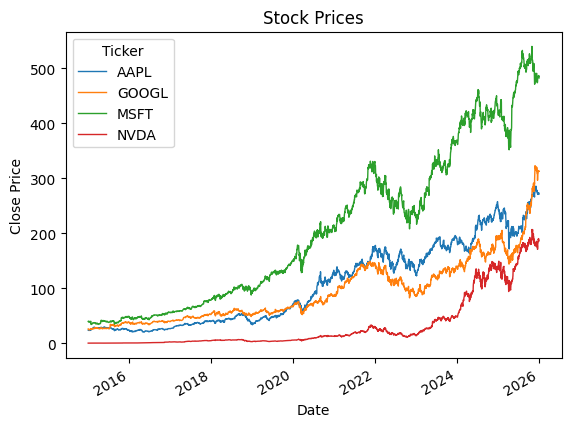

In [ ]:
df_close.plot(lw= 1, title = "Stock Prices", ylabel = "Close Price")

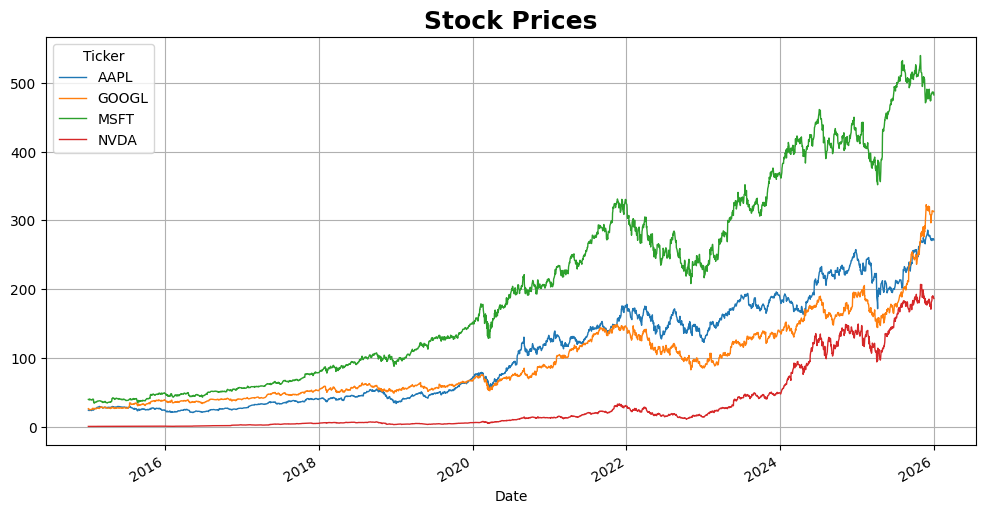

In [ ]:
ax = df_close.plot(lw=1,figsize=(12,6))
ax.set_title("Stock Prices", fontsize=18, fontweight="bold")
ax.grid(True)

## Creating a Scatter Plot

This example creates a scatter plot using Apple's opening prices.


<Axes: xlabel='(Open, AAPL)', ylabel='(Close, AAPL)'>

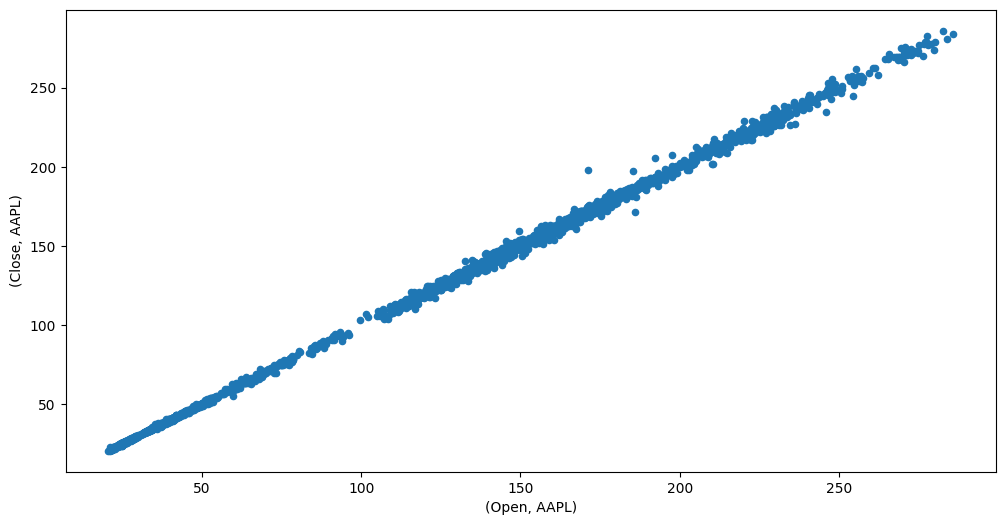

In [10]:
data.plot.scatter(x = ("Open","AAPL"), y = ("Close","AAPL"),figsize=(12,6))

## Scatter Plot with a Regression Line

This example compares Apple's opening and closing prices and adds a fitted regression line.


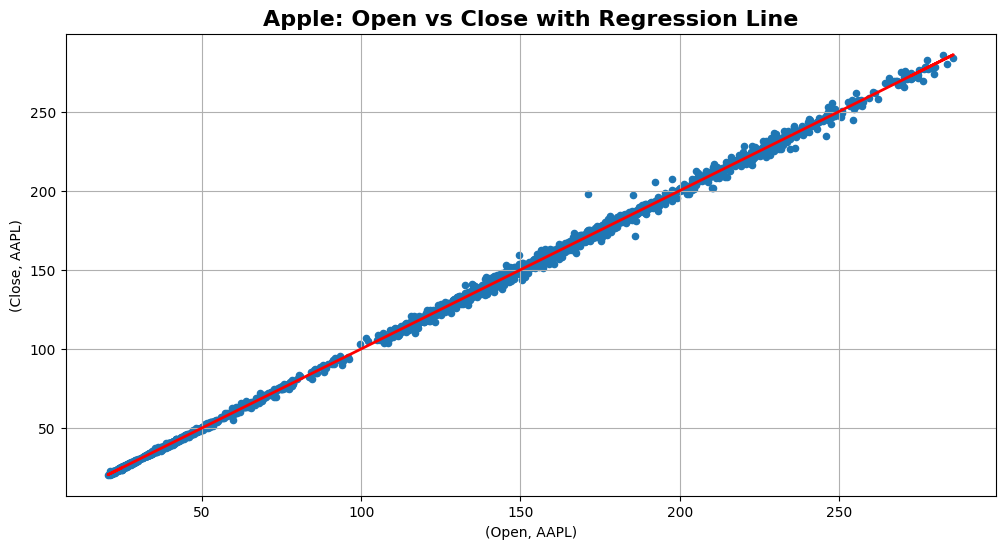

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ax = data.plot.scatter(x=("Open","AAPL"), y=("Close","AAPL"), figsize=(12,6))

x = data[("Open","AAPL")]
y = data[("Close","AAPL")]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red", linewidth=2)

plt.title("Apple: Open vs Close with Regression Line", fontsize=16, fontweight="bold")
plt.grid(True)
plt.show()

## Downloading Stock Price Data for Turkish Companies

This code downloads daily stock data for selected Borsa İstanbul companies.


In [ ]:
stock_symbol = ["ASELS.IS","THYAO.IS","BIMAS.IS","ARCLK.IS"]
start_date = "2020-01-01"
end_date = "2026-04-03"
data_tr = yf.download(stock_symbol, start=start_date, end=end_date, interval ="1d")

/tmp/ipykernel_10509/2624590714.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_tr = yf.download(stock_symbol, start=start_date, end=end_date, interval ="1d")
[*********************100%***********************]  4 of 4 completed


## Plotting Closing Prices for Turkish Stocks

The following chart visualizes the closing prices of the selected Turkish stocks.


<Axes: title={'center': 'Stock Prices'}, xlabel='Date', ylabel='Close Price'>

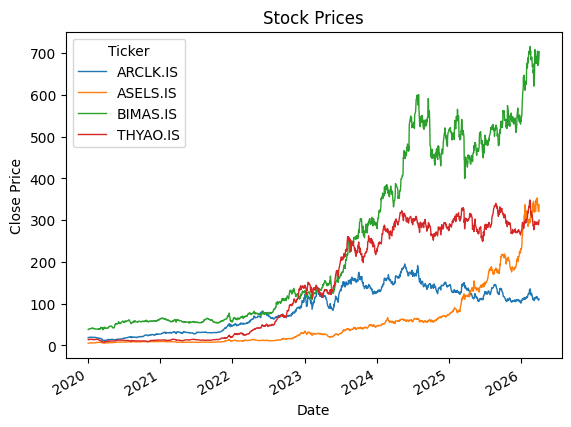

In [ ]:
df_close_tr = data_tr["Close"]
df_close_tr.plot(lw=1, title="Stock Prices", ylabel="Close Price")